# **Librerias**

In [1]:
import pandas as pd
import numpy as np
import random
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

#Para garantizar reproducibilidad en resultados
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from sklearn.model_selection import train_test_split as sklearn_train_test_split


# **Carga de datos**

In [2]:
# ── Paths
ROOT       = Path('..')
DATA_DIR   = ROOT / 'data'
RAW_DIR   = DATA_DIR / 'raw' # yelp JSONs live here
PROCESSED_DIR = DATA_DIR / 'processed' # processed data will be saved here
MODEL_DIR = ROOT / 'models' # trained model will be saved here
FIGS_DIR = ROOT / 'figs' # figures will be saved here

# create directories if they don't exist
for directory in [DATA_DIR, RAW_DIR, PROCESSED_DIR, MODEL_DIR, FIGS_DIR]:
    if not directory.exists():
        directory.mkdir()

Dado que los archivos son gigantes, se decidió cargar por chunks (1 millón de lineas cada uno, en total son alrededor de 7 chunks para el archivo más grande), y luego guardar en formato parquet para luego re-cargarlo completo en parquet, parece redundante pero ahorra mucha ram y tiempo en los archivos pesados

In [3]:
raw_json_paths = list(RAW_DIR.glob('*.json'))
create_parquets = any(not (RAW_DIR / f"{json_path.stem}.parquet").exists() for json_path in raw_json_paths)
if create_parquets:
    # --- IGNORE ---
    for json_path in raw_json_paths:
        with open(json_path, 'r') as f:
            
            chunksize = 1e6
            yelp_data = []
            yelp_chunks = pd.read_json(json_path, lines=True, chunksize=chunksize)
            for chunk in yelp_chunks:
                yelp_data.append(chunk)

            # guardar en parquet
            pd.concat(yelp_data).to_parquet(Path(json_path.parent,f"{json_path.stem}.parquet"), index=False)
            #yelp_data:pd.DataFrame = pd.read_parquet(Path(json_path.parent,f"{json_path.stem}.parquet"))
else:
    print("Parquet files already exist. Skipping JSON to Parquet conversion.")

Parquet files already exist. Skipping JSON to Parquet conversion.


### **`df_reviews`**: Almacena las reviews que los usuarios han dado a los negocios.

In [4]:
print("Loading reviews")
df_reviews = pd.read_parquet(RAW_DIR / 'yelp_academic_dataset_review.parquet', engine='fastparquet')
print(f"hay {df_reviews.shape[0]} filas en reviews")
print(df_reviews.columns, "\n")

Loading reviews
hay 6990280 filas en reviews
Index(['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny',
       'cool', 'text', 'date'],
      dtype='object') 



In [5]:
display(df_reviews.info())
print("Numero de usuarios unicos:", df_reviews["user_id"].nunique())
print("Numero de peliculas unicas:", df_reviews['business_id'].nunique())
display(df_reviews)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6990280 entries, 0 to 6990279
Data columns (total 9 columns):
 #   Column       Dtype         
---  ------       -----         
 0   review_id    object        
 1   user_id      object        
 2   business_id  object        
 3   stars        int64         
 4   useful       int64         
 5   funny        int64         
 6   cool         int64         
 7   text         object        
 8   date         datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 480.0+ MB


None

Numero de usuarios unicos: 1987929
Numero de peliculas unicas: 150346


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
...,...,...,...,...,...,...,...,...,...
6990275,H0RIamZu0B0Ei0P4aeh3sQ,qskILQ3k0I_qcCMI-k6_QQ,jals67o91gcrD4DC81Vk6w,5,1,2,1,Latest addition to services from ICCU is Apple...,2014-12-17 21:45:20
6990276,shTPgbgdwTHSuU67mGCmZQ,Zo0th2m8Ez4gLSbHftiQvg,2vLksaMmSEcGbjI5gywpZA,5,2,1,2,"This spot offers a great, affordable east week...",2021-03-31 16:55:10
6990277,YNfNhgZlaaCO5Q_YJR4rEw,mm6E4FbCMwJmb7kPDZ5v2Q,R1khUUxidqfaJmcpmGd4aw,4,1,0,0,This Home Depot won me over when I needed to g...,2019-12-30 03:56:30
6990278,i-I4ZOhoX70Nw5H0FwrQUA,YwAMC-jvZ1fvEUum6QkEkw,Rr9kKArrMhSLVE9a53q-aA,5,1,0,0,For when I'm feeling like ignoring my calorie-...,2022-01-19 18:59:27


In [6]:
print(f"El archivo business.json contiene {df_reviews.shape[0]} reviews realizadas por {df_reviews["user_id"].nunique()} usuarios acerca de {df_reviews['business_id'].nunique()} ítems (negocios). ")

El archivo business.json contiene 6990280 reviews realizadas por 1987929 usuarios acerca de 150346 ítems (negocios). 


### **`df_business`**: Contiene información de cada negocio.

In [7]:
print("Loading businesses")
df_businesses = pd.read_parquet(RAW_DIR / 'yelp_academic_dataset_business.parquet', engine='fastparquet')
print(f"hay {df_businesses.shape[0]} filas en businesses")
print(df_businesses.columns, "\n")

Loading businesses
hay 150346 filas en businesses
Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'categories', 'attributes.ByAppointmentOnly',
       'attributes.BusinessAcceptsCreditCards', 'attributes.BikeParking',
       'attributes.RestaurantsPriceRange2', 'attributes.CoatCheck',
       'attributes.RestaurantsTakeOut', 'attributes.RestaurantsDelivery',
       'attributes.Caters', 'attributes.WiFi', 'attributes.BusinessParking',
       'attributes.WheelchairAccessible', 'attributes.HappyHour',
       'attributes.OutdoorSeating', 'attributes.HasTV',
       'attributes.RestaurantsReservations', 'attributes.DogsAllowed',
       'attributes.Alcohol', 'attributes.GoodForKids',
       'attributes.RestaurantsAttire', 'attributes.Ambience',
       'attributes.RestaurantsTableService',
       'attributes.RestaurantsGoodForGroups', 'attributes.DriveThru',
       'attributes.NoiseLevel', 'attri

In [8]:
print("Numero de negocios unicos:", df_businesses['business_id'].nunique())
display(df_businesses.info())
display(df_businesses)

Numero de negocios unicos: 150346
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 58 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   business_id                            150346 non-null  object 
 1   name                                   150346 non-null  object 
 2   address                                150346 non-null  object 
 3   city                                   150346 non-null  object 
 4   state                                  150346 non-null  object 
 5   postal_code                            150346 non-null  object 
 6   latitude                               150346 non-null  float64
 7   longitude                              150346 non-null  float64
 8   stars                                  150346 non-null  float64
 9   review_count                           150346 non-null  int64  
 10  is_open               

None

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,attributes.RestaurantsCounterService,attributes.AgesAllowed,attributes.DietaryRestrictions,hours.Monday,hours.Tuesday,hours.Wednesday,hours.Thursday,hours.Friday,hours.Saturday,hours.Sunday
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,None,None,None,None,None,None,None,None,None,None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,None,None,None,0:0-0:0,8:0-18:30,8:0-18:30,8:0-18:30,8:0-18:30,8:0-14:0,None
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,...,None,None,None,8:0-22:0,8:0-22:0,8:0-22:0,8:0-22:0,8:0-23:0,8:0-23:0,8:0-22:0
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,None,None,None,7:0-20:0,7:0-20:0,7:0-20:0,7:0-20:0,7:0-21:0,7:0-21:0,7:0-21:0
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,...,None,None,None,None,None,14:0-22:0,16:0-22:0,12:0-22:0,12:0-22:0,12:0-18:0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150341,IUQopTMmYQG-qRtBk-8QnA,Binh's Nails,3388 Gateway Blvd,Edmonton,AB,T6J 5H2,53.468419,-113.492054,3.0,13,...,None,None,None,10:0-19:30,10:0-19:30,10:0-19:30,10:0-19:30,10:0-19:30,10:0-17:30,11:0-17:0
150342,c8GjPIOTGVmIemT7j5_SyQ,Wild Birds Unlimited,2813 Bransford Ave,Nashville,TN,37204,36.115118,-86.766925,4.0,5,...,None,None,None,9:30-17:30,9:30-17:30,9:30-17:30,9:30-17:30,9:30-17:30,9:0-17:0,0:0-16:0
150343,_QAMST-NrQobXduilWEqSw,Claire's Boutique,"6020 E 82nd St, Ste 46",Indianapolis,IN,46250,39.908707,-86.065088,3.5,8,...,None,None,None,None,None,None,None,None,None,None
150344,mtGm22y5c2UHNXDFAjaPNw,Cyclery & Fitness Center,2472 Troy Rd,Edwardsville,IL,62025,38.782351,-89.950558,4.0,24,...,None,None,None,9:0-20:0,9:0-20:0,9:0-20:0,9:0-20:0,9:0-20:0,9:0-17:0,10:0-17:0


In [9]:
print(f"El archivo business.json contiene la información referente a las  {df_businesses.shape[0]} negocios tales como nombre del negocio, ciudad, horario, categorias y atributos.")

El archivo business.json contiene la información referente a las  150346 negocios tales como nombre del negocio, ciudad, horario, categorias y atributos.


#### calificación promedio de la pelicula

In [10]:
# Calculamos el rating promedio para cada pelicula agrupando por 'business_id' y calculando la media de la columna 'stars'
average_ratings = df_reviews.groupby("business_id")["stars"].mean().reset_index()
average_ratings 

,business_id,stars
0,---kPU91CF4Lq2-WlRu9Lw,4.500000
1,--0iUa4sNDFiZFrAdIWhZQ,3.214286
2,--30_8IhuyMHbSOcNWd6DQ,3.555556
3,--7PUidqRWpRSpXebiyxTg,1.750000
4,--7jw19RH9JKXgFohspgQw,4.230769
...,...,...
150341,zznZqH9CiAznbkV6fXyHWA,4.916667
150342,zztOG2cKm87I6Iw_tleZsQ,4.833333
150343,zzu6_r3DxBJuXcjnOYVdTw,3.625000
150344,zzw66H6hVjXQEt0Js3Mo4A,3.600000


In [11]:
def average_rating_weighted_by_user_activity(df_ratings, df_items):
    """Calcula el promedio bayesiano de las calificaciones de las items, 
    ponderado por la actividad de los usuarios."""
    items_stats = df_ratings.groupby('business_id')['stars'].agg({'count','mean','var'}).reset_index()

    # 1. Calcular C (el promedio global de todas las calificaciones)
    C = items_stats['mean'].mean()

    # 2. Calcular m (el mínimo de votos requeridos). ``
    # Aquí usamos el percentil 90: el item debe tener más votos que el 90% de la base de datos
    m = items_stats['count'].quantile(0.90)

    print(f"Promedio global ratings (C): {C:.2f}")
    print(f"Cantidad de ratings mínimos (m) - Percentil 90: {m}")


    # 3. Definir la función del Promedio Bayesiano
    def weighted_rating(x, m=m, C=C):
        v = x['count']
        R = x['mean']
        # Fórmula
        return (v/(v+m) * R) + (m/(m+v) * C)
    
    items_stats['score_bayesiano'] = items_stats.apply(weighted_rating, axis=1)
    return items_stats[['score_bayesiano', 'business_id']].merge(df_items, on='business_id', how='left')

items_with_bayesian_score = average_rating_weighted_by_user_activity(df_reviews, df_businesses)
items_with_bayesian_score.sort_values('score_bayesiano', ascending=False)[['business_id', 'score_bayesiano', 'name', 'review_count']].head(10)

Promedio global ratings (C): 3.59
Cantidad de ratings mínimos (m) - Percentil 90: 101.0


,business_id,score_bayesiano,name,review_count
150248,zxIF-bnaJ-eKIsznB7yu7A,4.712078,Free Tours By Foot,769
34320,DVBJRvnCpkqaYl6nHroaMg,4.698595,Tumerico,705
88194,_aKr7POnacW_VizRKBpCiA,4.681153,Blues City Deli,991
56736,NDwoKO79_T49UEKVDlHd3A,4.680989,Sustainable Wine Tours,358
22416,8QqnRpM-QxGsjDNuu0E57A,4.677058,Carlillos Cocina,799
104116,gP_oWJykA2RocIs_GurKWQ,4.671194,Yats,623
59589,OR7VJQ3Nk1wCcIbPN4TCQQ,4.648217,Smiling With Hope Pizza,526
121351,nk96iwJV1_p2HECYQW1ysA,4.640838,French Quarter Phantoms,1481
42231,GuzbBFraIq-fbkjfvaTRvg,4.623709,Mesa Verde,1796
48406,JbzvJJolDBT1614qo2Yiaw,4.620155,Nelson's Green Brier Distillery,545


#### `attributes`

In [12]:
attributes_columns = df_businesses.filter(regex='attributes.').columns
print(attributes_columns)
df_businesses[["name"] + list(attributes_columns)].head()

Index(['attributes.ByAppointmentOnly', 'attributes.BusinessAcceptsCreditCards',
       'attributes.BikeParking', 'attributes.RestaurantsPriceRange2',
       'attributes.CoatCheck', 'attributes.RestaurantsTakeOut',
       'attributes.RestaurantsDelivery', 'attributes.Caters',
       'attributes.WiFi', 'attributes.BusinessParking',
       'attributes.WheelchairAccessible', 'attributes.HappyHour',
       'attributes.OutdoorSeating', 'attributes.HasTV',
       'attributes.RestaurantsReservations', 'attributes.DogsAllowed',
       'attributes.Alcohol', 'attributes.GoodForKids',
       'attributes.RestaurantsAttire', 'attributes.Ambience',
       'attributes.RestaurantsTableService',
       'attributes.RestaurantsGoodForGroups', 'attributes.DriveThru',
       'attributes.NoiseLevel', 'attributes.GoodForMeal',
       'attributes.BusinessAcceptsBitcoin', 'attributes.Smoking',
       'attributes.Music', 'attributes.GoodForDancing',
       'attributes.AcceptsInsurance', 'attributes.BestNights',


,name,attributes.ByAppointmentOnly,attributes.BusinessAcceptsCreditCards,attributes.BikeParking,attributes.RestaurantsPriceRange2,attributes.CoatCheck,attributes.RestaurantsTakeOut,attributes.RestaurantsDelivery,attributes.Caters,attributes.WiFi,...,attributes.AcceptsInsurance,attributes.BestNights,attributes.BYOB,attributes.Corkage,attributes.BYOBCorkage,attributes.HairSpecializesIn,attributes.Open24Hours,attributes.RestaurantsCounterService,attributes.AgesAllowed,attributes.DietaryRestrictions
0,"Abby Rappoport, LAC, CMQ",True,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,The UPS Store,None,True,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,Target,False,True,True,2,False,False,False,False,u'no',...,None,None,None,None,None,None,None,None,None,None
3,St Honore Pastries,False,False,True,1,None,True,False,True,u'free',...,None,None,None,None,None,None,None,None,None,None
4,Perkiomen Valley Brewery,None,True,True,None,None,True,None,False,None,...,None,None,None,None,None,None,None,None,None,None


In [13]:
hours_columns = list(df_businesses.filter(regex='hours.').columns)

# Diccionario con los horarios de cada negocio
df_businesses["hours"] = df_businesses.apply(lambda row: {day.split(".")[1]: row[day] for day in hours_columns if pd.notna(row[day])}, axis=1)
df_businesses[["name", "hours"] + hours_columns ].head()

,name,hours,hours.Monday,hours.Tuesday,hours.Wednesday,hours.Thursday,hours.Friday,hours.Saturday,hours.Sunday
0,"Abby Rappoport, LAC, CMQ",{},None,None,None,None,None,None,None
1,The UPS Store,"{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ...",0:0-0:0,8:0-18:30,8:0-18:30,8:0-18:30,8:0-18:30,8:0-14:0,None
2,Target,"{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ...",8:0-22:0,8:0-22:0,8:0-22:0,8:0-22:0,8:0-23:0,8:0-23:0,8:0-22:0
3,St Honore Pastries,"{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",7:0-20:0,7:0-20:0,7:0-20:0,7:0-20:0,7:0-21:0,7:0-21:0,7:0-21:0
4,Perkiomen Valley Brewery,"{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2...",None,None,14:0-22:0,16:0-22:0,12:0-22:0,12:0-22:0,12:0-18:0


### `df_user`: usuarios

In [14]:
print("Loading users")
df_users = pd.read_parquet(RAW_DIR / 'yelp_academic_dataset_user.parquet', engine='fastparquet')
print(f"hay {df_users.shape[0]} filas en users")
display(df_users.info())
display(df_users.head())

Loading users
hay 1987897 filas en users
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987897 entries, 0 to 1987896
Data columns (total 22 columns):
 #   Column              Dtype  
---  ------              -----  
 0   user_id             object 
 1   name                object 
 2   review_count        int64  
 3   yelping_since       object 
 4   useful              int64  
 5   funny               int64  
 6   cool                int64  
 7   elite               object 
 8   friends             object 
 9   fans                int64  
 10  average_stars       float64
 11  compliment_hot      int64  
 12  compliment_more     int64  
 13  compliment_profile  int64  
 14  compliment_cute     int64  
 15  compliment_list     int64  
 16  compliment_note     int64  
 17  compliment_plain    int64  
 18  compliment_cool     int64  
 19  compliment_funny    int64  
 20  compliment_writer   int64  
 21  compliment_photos   int64  
dtypes: float64(1), int64(16), object(5)
memory usage:

None

,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0


In [15]:
print("Numero de usuarios unicos:", df_reviews["user_id"].nunique())
print("Numero de negocios unicos:", df_reviews['business_id'].nunique())
print("Numero de calificaciones:", df_reviews['stars'].shape[0])

Numero de usuarios unicos: 1987929
Numero de negocios unicos: 150346
Numero de calificaciones: 6990280


# **Exploración de Datos**

## Distribución de ratings

In [16]:
conteo = df_reviews['stars'].value_counts().sort_index()
conteo

stars
1    1069561
2     544240
3     691934
4    1452918
5    3231627
Name: count, dtype: int64

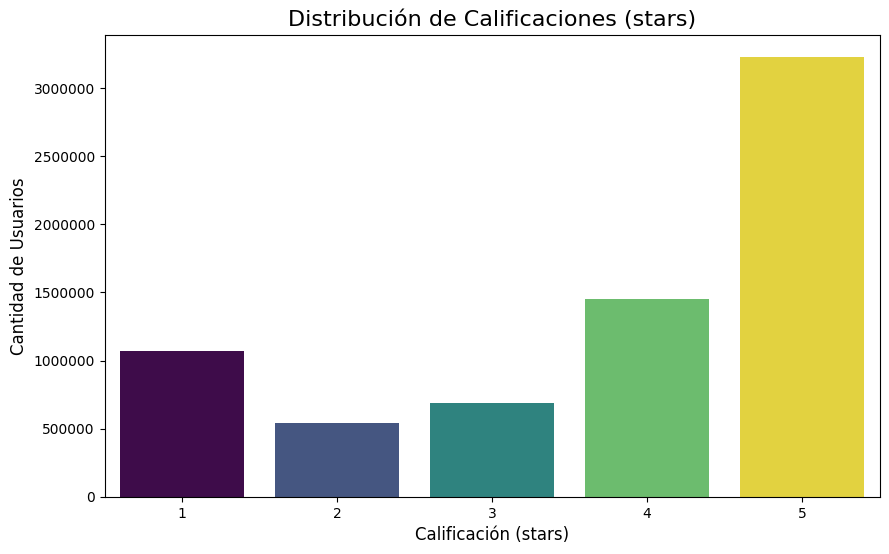

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Creamos el gráfico directamente desde el DataFrame
sns.countplot(data=df_reviews, x='stars', hue='stars', palette='viridis', legend=False)

# Añadir títulos y formato
plt.title('Distribución de Calificaciones (stars)', fontsize=16)
plt.xlabel('Calificación (stars)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Formatear el eje Y para que no muestre notación científica (ej. 1e6)
plt.ticklabel_format(style='plain', axis='y')

plt.savefig(FIGS_DIR / 'dist_ratings.png')

plt.show()

In [18]:
x = (df_reviews['stars'].value_counts().sort_index() / df_reviews.shape[0])*100
x

stars
1    15.300689
2     7.785668
3     9.898516
4    20.784833
5    46.230294
Name: count, dtype: float64

In [19]:
x.cumsum()

stars
1     15.300689
2     23.086357
3     32.984873
4     53.769706
5    100.000000
Name: count, dtype: float64

La distribución de las calificaciones (ratings) se presenta en la Figura 1.  La variable stars es una variable que toma valores discretos enteros entre 1 y 5. Se observa una concentración en calificaciones altas de las escala. La calificación más frecuente (46%) es 5.0 y la mediana es 4.0 . El 33% de las calificaciones son 3 o menos. 

## ¿Cómo es la distribución del número de ratings por usuario?



In [20]:
user_stats =df_reviews.groupby("user_id")['stars'].agg({'count','mean'}).sort_values(by='count', ascending=False)
user_stats

,count,mean
user_id,,
_BcWyKQL16ndpBdggh2kNA,3048,3.637795
Xw7ZjaGfr0WNVt6s_5KZfA,1840,4.072826
0Igx-a1wAstiBDerGxXk2A,1747,3.990269
-G7Zkl1wIWBBmD0KRy_sCw,1682,3.652794
ET8n-r7glWYqZhuR6GcdNw,1653,4.046582
...,...,...
Q3vRxWvwiqyTnsNqlVFJgQ,1,2.000000
Q3usHTFn9UhwoMfos5XczA,1,5.000000
Q3toekMAlCz8VrMyU8oo4w,1,1.000000


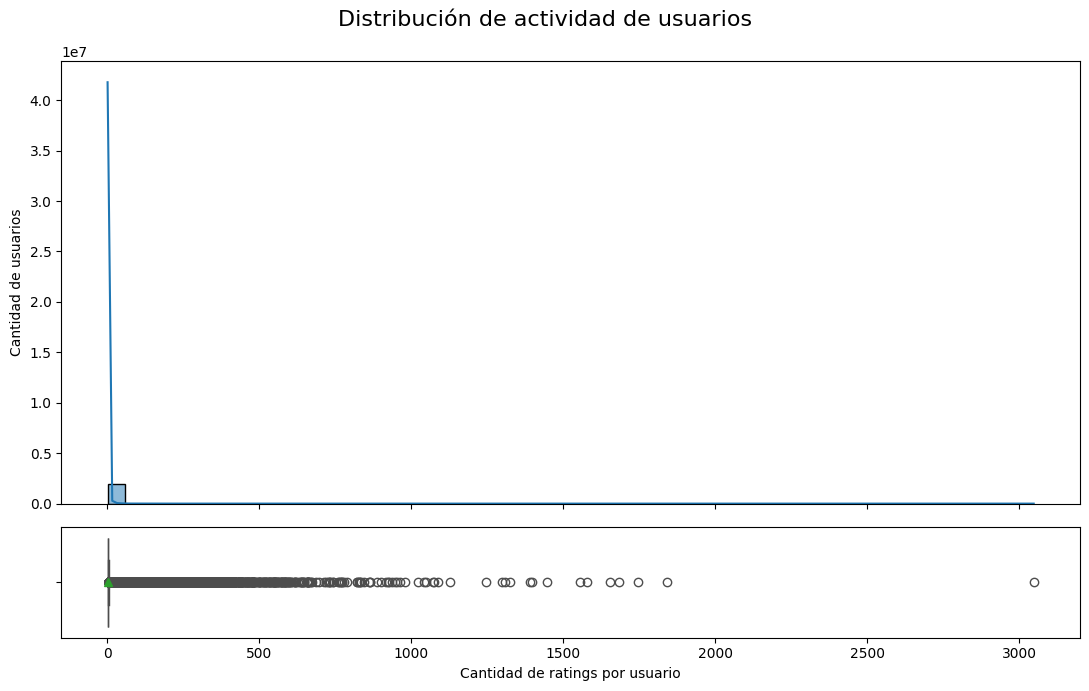

count    1.987929e+06
mean     3.516363e+00
std      1.277088e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      3.048000e+03
Name: count, dtype: float64

In [21]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,7),
    sharex=True,
    gridspec_kw={'height_ratios':[4,1]}  # hist grande, box pequeño
)

# Histograma
sns.histplot(
    data=user_stats,
    x='count',
    bins=52,
    kde=True,
    ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel('Cantidad de usuarios')


# Boxplot
sns.boxplot(
    data=user_stats,
    x='count',
    ax=ax2,
    color='orange',
    showmeans = True,
)

ax2.set_ylabel('')
ax2.set_xlabel('')

plt.suptitle('Distribución de actividad de usuarios', fontsize=16)
plt.xlabel('Cantidad de ratings por usuario')
plt.ylabel('')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'usuarios_actividad.png')
plt.show()
user_stats['count'].describe()

Al analizar la actividad de los usuarios (figura 2) se observa que el número de reviews por usuario presenta una distribución fuertemente asimétrica positiva (right-skewed) y de cola larga (long-tail distribution). Lo anterior nos indica que la mayoría de los usuarios califica pocos negocios, mientras que unos pocos califican muchísimas. Un usuario en el dataset califica entre 1 y 3048 peliculas. En promedio los usuarios realizan 3.51 calificaciones, sin embargo, la mayoria de los usuarios están muy por debajo del promedio: la mediana es de 1 calificación y solo el 25% de los usuarios supera 3 ratings. 

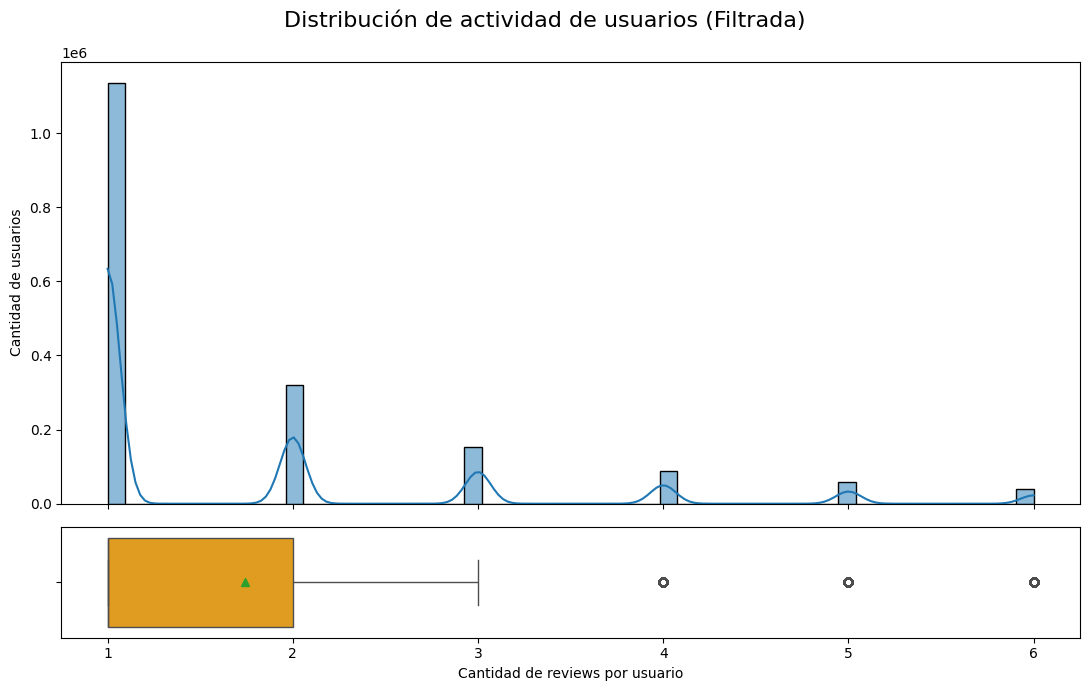

count    1.800161e+06
mean     1.741665e+00
std      1.225607e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      6.000000e+00
Name: count, dtype: float64

In [22]:
# eliminar outliers
Q1 = user_stats['count'].quantile(0.25)
Q3 = user_stats['count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
filtered_user_stats = user_stats[(user_stats['count'] >= lower_bound) & (user_stats['count'] <= upper_bound)]

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,7),
    sharex=True,
    gridspec_kw={'height_ratios':[4,1]}  # hist grande, box pequeño
)

# Histograma
sns.histplot(
    data=filtered_user_stats,
    x='count',
    bins=52,
    kde=True,
    ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel('Cantidad de usuarios')


# Boxplot
sns.boxplot(
    data=filtered_user_stats,
    x='count',
    ax=ax2,
    color='orange',
    showmeans = True,
)

ax2.set_ylabel('')
ax2.set_xlabel('')

plt.suptitle('Distribución de actividad de usuarios (Filtrada)', fontsize=16)
plt.xlabel('Cantidad de reviews por usuario')
plt.ylabel('')
plt.tight_layout()
plt.show()
filtered_user_stats['count'].describe()

## ¿Cómo es la distribución del promedio de calificación por usuario?

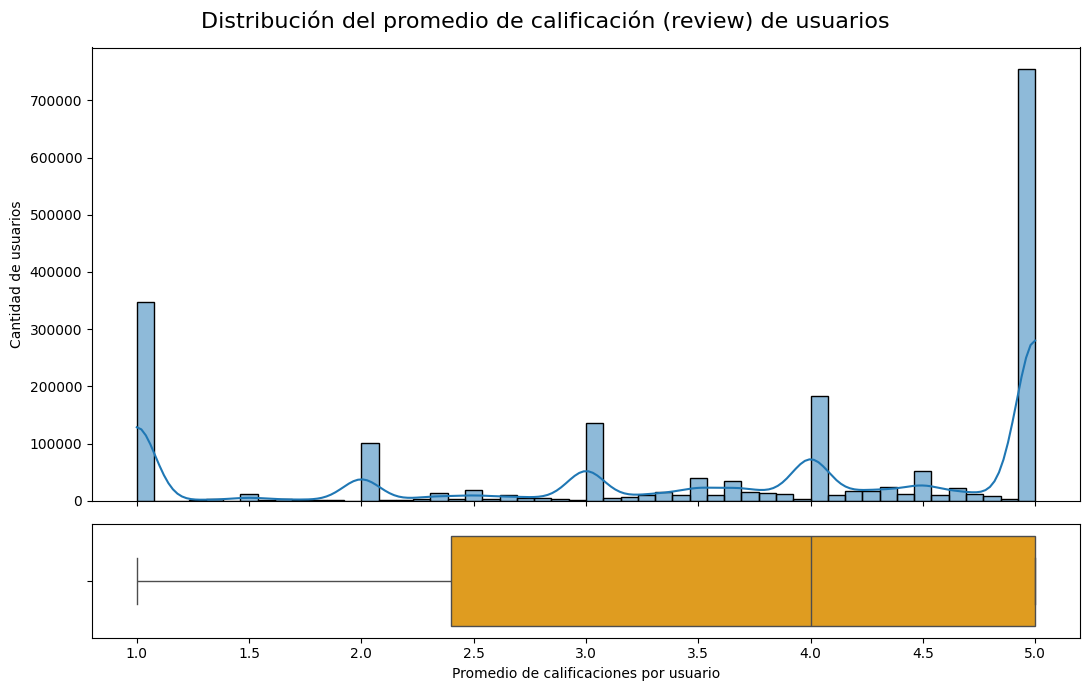

count    1.987929e+06
mean     3.604842e+00
std      1.507412e+00
min      1.000000e+00
25%      2.400000e+00
50%      4.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: mean, dtype: float64

In [23]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,7),
    sharex=True,
    gridspec_kw={'height_ratios':[4,1]}  # hist grande, box pequeño
)

# Histograma
sns.histplot(
    data=user_stats,
    x='mean',
    bins=52,
    kde=True,
    ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel('Cantidad de usuarios')


# Boxplot
sns.boxplot(
    data=user_stats,
    x='mean',
    ax=ax2,
    color='orange'
)

ax2.set_ylabel('')
ax2.set_xlabel('')

plt.suptitle('Distribución del promedio de calificación (review) de usuarios', fontsize=16)
plt.xlabel('Promedio de calificaciones por usuario')
plt.ylabel('')
plt.tight_layout()
plt.savefig(FIGS_DIR /'usuarios_promedio.png')
plt.show()
user_stats['mean'].describe()


La distribución del promedio de calificaciones ...

## Estadisticas de los items

In [24]:
items_stats = df_reviews.groupby('business_id')['stars'].agg({'count','mean','var'}).reset_index().join(df_businesses['name'], how='left')
items_stats

,business_id,count,mean,var,name
0,---kPU91CF4Lq2-WlRu9Lw,24,4.500000,0.956522,"Abby Rappoport, LAC, CMQ"
1,--0iUa4sNDFiZFrAdIWhZQ,14,3.214286,1.873626,The UPS Store
2,--30_8IhuyMHbSOcNWd6DQ,9,3.555556,3.777778,Target
3,--7PUidqRWpRSpXebiyxTg,12,1.750000,1.113636,St Honore Pastries
4,--7jw19RH9JKXgFohspgQw,13,4.230769,2.358974,Perkiomen Valley Brewery
...,...,...,...,...,...
150341,zznZqH9CiAznbkV6fXyHWA,12,4.916667,0.083333,Binh's Nails
150342,zztOG2cKm87I6Iw_tleZsQ,6,4.833333,0.166667,Wild Birds Unlimited
150343,zzu6_r3DxBJuXcjnOYVdTw,8,3.625000,0.839286,Claire's Boutique
150344,zzw66H6hVjXQEt0Js3Mo4A,5,3.600000,3.800000,Cyclery & Fitness Center


### Distribución del número de calificaciones (review) por negocio

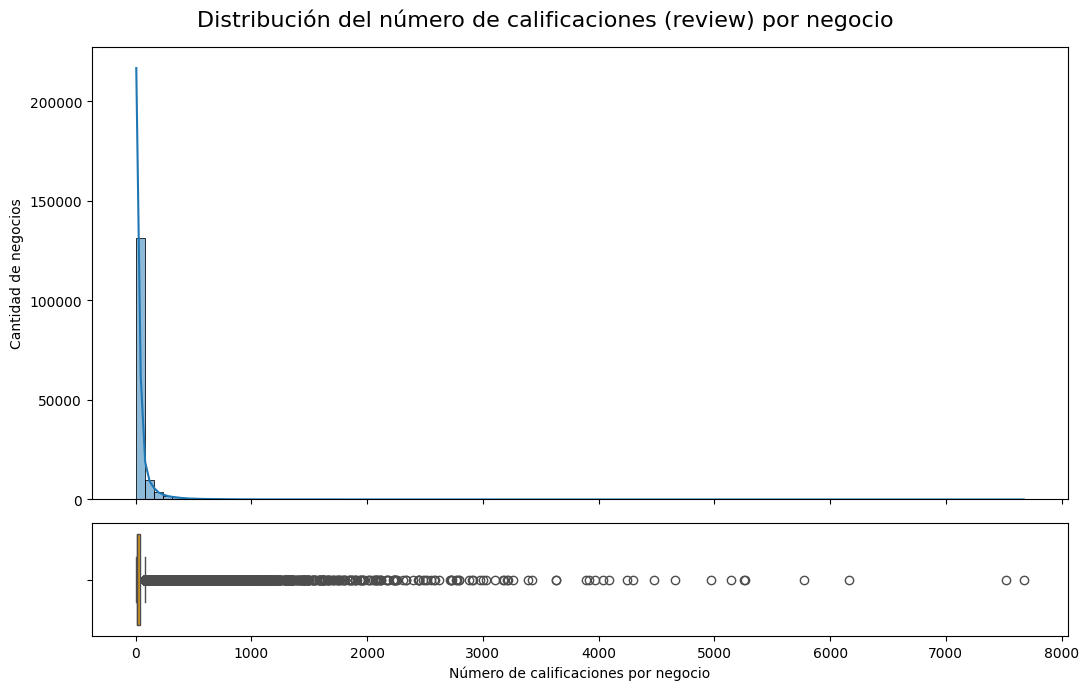

Distribución del número de calificaciones (review) por negocio


count    150346.000000
mean         46.494619
std         124.519061
min           5.000000
10%           6.000000
20%           7.000000
25%           8.000000
30%           9.000000
40%          11.000000
50%          15.000000
60%          21.000000
70%          31.000000
75%          38.000000
80%          50.000000
90%         101.000000
max        7673.000000
Name: count, dtype: float64

In [25]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,7),
    sharex=True,
    gridspec_kw={'height_ratios':[4,1]}  # hist grande, box pequeño
)

# Histograma
sns.histplot(
    data=items_stats,
    x='count',
    bins=100,
    kde=True,
    ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel('Cantidad de negocios')


# Boxplot
sns.boxplot(
    data=items_stats,
    x='count',
    ax=ax2,
    color='orange'
)

ax2.set_ylabel('')
ax2.set_xlabel('')

plt.suptitle('Distribución del número de calificaciones (review) por negocio', fontsize=16)
plt.xlabel('Número de calificaciones por negocio')
plt.ylabel('')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'items_actividad.png')
plt.show()
print('Distribución del número de calificaciones (review) por negocio')
items_stats['count'].describe(percentiles=[0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7,0.75, 0.8, 0.9])

### Distribución del promedio de calificaciones (review) por negocio

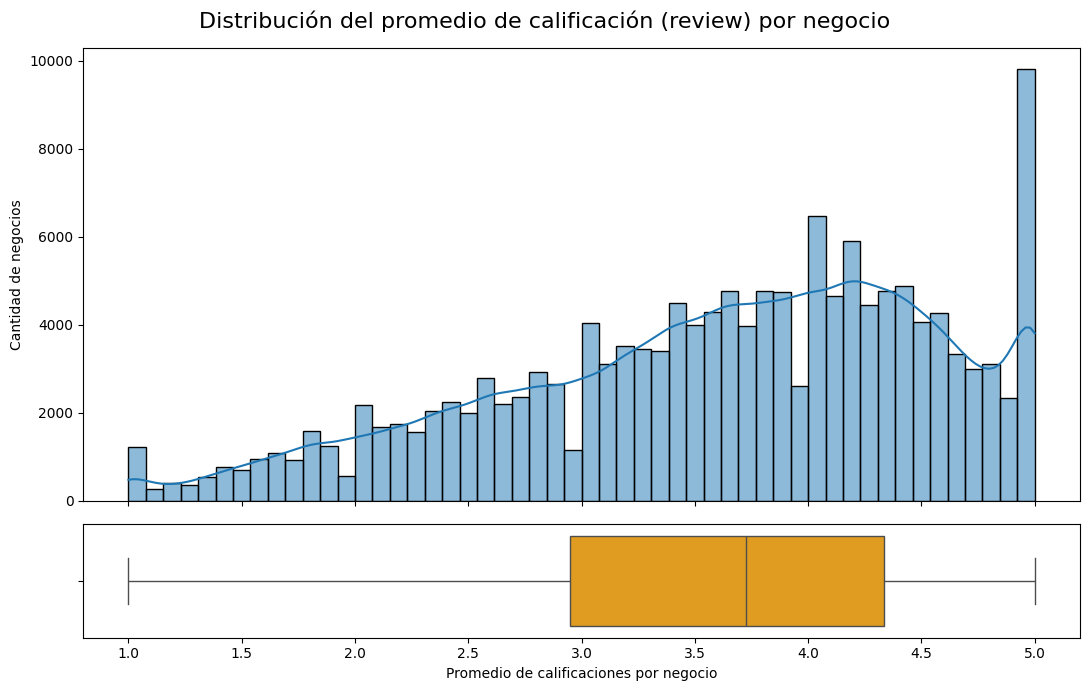

Distribución del promedio de calificación (review) por negocio


count    150346.000000
mean          3.587534
std           0.961807
min           1.000000
25%           2.948718
50%           3.727273
75%           4.333333
max           5.000000
Name: mean, dtype: float64

In [26]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,7),
    sharex=True,
    gridspec_kw={'height_ratios':[4,1]}  # hist grande, box pequeño
)

# Histograma
sns.histplot(
    data=items_stats,
    x='mean',
    bins=52,
    kde=True,
    ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel('Cantidad de negocios')


# Boxplot
sns.boxplot(
    data=items_stats,
    x='mean',
    ax=ax2,
    color='orange'
)

ax2.set_ylabel('')
ax2.set_xlabel('')

plt.suptitle('Distribución del promedio de calificación (review) por negocio', fontsize=16)
plt.xlabel('Promedio de calificaciones por negocio')
plt.ylabel('')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'items_promedio.png')
plt.show()
print('Distribución del promedio de calificación (review) por negocio')
items_stats['mean'].describe()

# **Muestreo Estratificado**

Con ayuda de `train_test_split` de scikit-learn creamos un muestreo estratificado de la actividad de los usuarios. El objetivo es quedarnos con el 10% de los usuarios (aproximadamente 13000) que representen la actividad general de los usuarios en el dataset.

In [27]:
def sample_users(df_reviews, df_items, df_users, test_size=0.9, random_state=SEED):
    
    user_stats = df_reviews.groupby("user_id")['stars'].agg({'count','mean'}).sort_values(by='count', ascending=False)

    # PASO 1: Crear "grupos de actividad" para la estratificación
    # Dividimos a los usuarios en 10 grupos (deciles) según su cantidad de calificaciones.
    # duplicates='drop' es por si hay muchos usuarios con el mismo número exacto de votos.
    user_stats['activity_group'] = pd.qcut(
        user_stats['count'], 
        q=3, 
        labels=False, 
        duplicates='drop'
    )

    # PASO 2: Crear grupos de calificación promedio 
    # para ayudar a mantener la distribución de reviews
    user_stats['review_group'] = pd.qcut(
        user_stats['mean'], 
        q=5, 
        labels=False,       
        duplicates='drop'
    )

    # PASO 3: Crear un grupo combinado de actividad y review para una estratificación más robusta
    user_stats['activity_review_group'] = user_stats['activity_group'].astype(str)
    user_stats['activity_review_group'] += "_" + user_stats['review_group'].astype(str)

    items_stats = df_reviews.groupby('business_id')['stars'].agg({'count','mean','var'})

    # PASO 4: 
    items_stats['activity_group'] = pd.qcut(
        items_stats['count'], 
        q=3, 
        labels=False, 
        duplicates='drop'
    )

    # PASO 5
    items_stats['rating_group'] = pd.qcut(
        items_stats['mean'], 
        q=5, 
        labels=False, 
        duplicates='drop'
    )

    items_stats['activity_review_group'] = items_stats['activity_group'].astype(str) + "_" + items_stats['rating_group'].astype(str)

    # PASO 6: Combinamos items_stats y user_stats con df_reviews para tener toda la información en un solo DataFrame
    df_reviews = df_reviews.merge(
        user_stats[['activity_review_group']],
        left_on='user_id',
        right_index=True,
        how='left'
    ).merge(
        items_stats[['activity_review_group']],
        left_on='business_id',
        right_index=True,
        how='left',
        suffixes=('_user', '_item')
    )

    df_reviews['activity_review_group'] = df_reviews['activity_review_group_user'].fillna('unknown') + "_" + df_reviews['activity_review_group_item'].fillna('unknown')

    group_counts = df_reviews["activity_review_group"].value_counts()
    rare_groups = group_counts[group_counts < 10].index

    df_reviews.loc[
        df_reviews["activity_review_group"].isin(rare_groups),
        "activity_review_group"
    ] = "rare"

    group_counts = df_reviews["activity_review_group"].value_counts()
    print("Grupos de actividad y review (después de combinar y limpiar):")
    display(group_counts)

    # PASO 7: Hacer el muestreo SOBRE LA TABLA DE USUARIOS (los 138k)
    reviews_sample, discarded_reviews = sklearn_train_test_split(
        df_reviews, 
        test_size= test_size, # Nos quedamos con el 10% de los usuarios (~13,800)
        stratify=df_reviews['activity_review_group'], # Estratificamos por su nivel de actividad
        random_state=SEED
    )
    # PASO 8: Filtrar la tabla gigante de calificaciones (los 20M)
    # Solo nos quedamos con las filas cuyo "user_id" esté dentro de nuestra muestra 
    user_sample = df_users[
        df_users["user_id"].isin(reviews_sample["user_id"].unique())
    ]
   

    # Conservamos en `df_items` solo los `business_id` presentes en `reviews_sample`.
    items_sample = df_items[df_items['business_id'].isin(reviews_sample['business_id'].unique())]

    print("Número de usuarios:", reviews_sample["user_id"].nunique())
    print("Número de negocios:", reviews_sample['business_id'].nunique())
    print(f"Calificaciones totales de estos usuarios: {reviews_sample.shape[0]}")

    return reviews_sample, items_sample, user_sample

In [28]:
reviews_sample, business_sample, user_sample = sample_users(df_reviews, df_businesses, df_users)

Grupos de actividad y review (después de combinar y limpiar):


activity_review_group
1_2_2_3    851880
1_2_2_2    792790
1_1_2_2    465680
1_1_2_3    386173
1_2_2_1    364296
            ...  
0_2_0_0      1241
1_0_0_3      1148
1_0_1_4      1130
1_0_0_4       654
0_0_0_4       564
Name: count, Length: 120, dtype: int64

Número de usuarios: 426080
Número de negocios: 114658
Calificaciones totales de estos usuarios: 699028


Revisamos la distribución de los ratings en el sample

In [29]:
def review_sample_rating(ratings_sample, df_ratings):
    print('Distribución de calificaciones (rating) en la muestra vs original')
    distribucion_sample = (ratings_sample['stars'].value_counts().sort_index()/ ratings_sample.shape[0]).round(4)
    distribucion_original = (df_ratings['stars'].value_counts().sort_index()/ df_ratings.shape[0]).round(4)
    diferencia_distribucion = (distribucion_sample - distribucion_original).round(4)
    df_temp = pd.DataFrame({
        'stars': distribucion_sample.index,
        "distribucion_sample": distribucion_sample.values,
        "distribucion_original": distribucion_original.values,
        "diferencia_distribucion": diferencia_distribucion.values
    })
    display(df_temp)
review_sample_rating(reviews_sample, df_reviews)

Distribución de calificaciones (rating) en la muestra vs original


,stars,distribucion_sample,distribucion_original,diferencia_distribucion
0,1,0.1528,0.1530,-0.0002
1,2,0.0777,0.0779,-0.0002
2,3,0.0989,0.0990,-0.0001
3,4,0.2080,0.2078,0.0002
4,5,0.4626,0.4623,0.0003


Revisamos la actividad de los usuarios en el sample

In [30]:
def calculate_stats(df_ratings, user_stats = True):
    """ Estadísticas descriptivas users/ítems"""
    group_by_col = "user_id" if user_stats else 'business_id'
    stats = df_ratings.groupby(group_by_col)['stars'].agg({'count','mean','var'}).reset_index()
    stats.rename(columns={'count':'num_ratings', 'mean':'average_rating', 'var':'rating_variance'}, inplace=True)
    return stats

def review_sample(df_ratings, ratings_sample, user_stats = True):

    original_stats = calculate_stats(ratings_sample, user_stats)
    sample_stats = calculate_stats(df_ratings, user_stats)

    title1 = 'Distribución de la actividad de usuarios' if user_stats else 'Distribución del número de calificaciones (rating) por película'
    df_num_ratings = pd.DataFrame({
        "num_ratings_sample": original_stats['num_ratings'],
        "num_ratings_original": sample_stats['num_ratings'],
    })
    print(title1)
    df1 = df_num_ratings.describe()
    df1["diferencia_num_ratings"] = (df1['num_ratings_sample'] - df1['num_ratings_original']).round(4)
    display(df1)

    title2 = 'Distribución del promedio de calificación (rating) de usuarios' if user_stats else 'Distribución del rating promedio por película'
    df_average_ratings = pd.DataFrame({
        "average_rating_sample": original_stats['average_rating'].round(4),
        "average_rating_original": sample_stats['average_rating'].round(4),
    })
    
    print(title2)
    df2 = df_average_ratings.describe()
    df2["diferencia_average_rating"] = (df2['average_rating_sample'] - df2['average_rating_original']).round(4)
    display(df2)

Revisamos la actividad de los usuarios en el sample

In [31]:
review_sample(df_reviews, reviews_sample, user_stats=True)    

Distribución de la actividad de usuarios


,num_ratings_sample,num_ratings_original,diferencia_num_ratings
count,426080.000000,1.987929e+06,-1.561849e+06
mean,1.640603,3.516363e+00,-1.875800e+00
std,2.663736,1.277088e+01,-1.010710e+01
min,1.000000,1.000000e+00,0.000000e+00
25%,1.000000,1.000000e+00,0.000000e+00
50%,1.000000,1.000000e+00,0.000000e+00
75%,1.000000,3.000000e+00,-2.000000e+00
max,329.000000,3.048000e+03,-2.719000e+03


Distribución del promedio de calificación (rating) de usuarios


,average_rating_sample,average_rating_original,diferencia_average_rating
count,426080.000000,1.987929e+06,-1.561849e+06
mean,3.697028,3.604842e+00,9.220000e-02
std,1.507257,1.507412e+00,-2.000000e-04
min,1.000000,1.000000e+00,0.000000e+00
25%,2.750000,2.400000e+00,3.500000e-01
50%,4.000000,4.000000e+00,0.000000e+00
75%,5.000000,5.000000e+00,0.000000e+00
max,5.000000,5.000000e+00,0.000000e+00


Revisamos las estadisticas de los items en el sample

In [32]:
review_sample(df_reviews, reviews_sample, user_stats=False)

Distribución del número de calificaciones (rating) por película


,num_ratings_sample,num_ratings_original,diferencia_num_ratings
count,114658.000000,150346.000000,-35688.0000
mean,6.096635,46.494619,-40.3980
std,14.127840,124.519061,-110.3912
min,1.000000,5.000000,-4.0000
25%,1.000000,8.000000,-7.0000
50%,2.000000,15.000000,-13.0000
75%,6.000000,38.000000,-32.0000
max,820.000000,7673.000000,-6853.0000


Distribución del rating promedio por película


,average_rating_sample,average_rating_original,diferencia_average_rating
count,114658.000000,150346.000000,-35688.0000
mean,3.589687,3.587534,0.0022
std,1.314091,0.961807,0.3523
min,1.000000,1.000000,0.0000
25%,2.866700,2.948700,-0.0820
50%,4.000000,3.727300,0.2727
75%,5.000000,4.333300,0.6667
max,5.000000,5.000000,0.0000


Guardamos los archivos para entrenamiento

In [33]:
reviews_sample.to_parquet(PROCESSED_DIR / 'reviews.parquet', index=False)
reviews_sample

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,activity_review_group_user,activity_review_group_item,activity_review_group
111017,1L3QDaiReMotRiVZQ0kLMA,ADnXRUR4i34df6MabjxT_A,10MHfI2mRKGJu_Vbm64pkQ,4,3,0,0,"It's a new (ok, recently changed owners) resta...",2014-02-28 14:23:39,1_1,1_1,1_1_1_1
2439728,WFWeabpHmMgtlWX-XVfbjg,MpWGzZxfQoAmHdkmwjhCiA,jmG_QxXXfz2cnw9dQCXJLQ,4,1,0,0,"Simple/Quick, Pastries, and Carbs.\n\nWith all...",2018-10-13 22:05:56,0_2,2_3,0_2_2_3
558003,GFWxrQBUUIPfeL-TtuiPSg,Jmqm-hHFndAPq5-eIiBRmQ,V1n-wIrt5xtI0VIAxIP5dA,3,1,1,0,The food was tasty. They weren't busy but the ...,2019-08-05 16:20:48,1_2,2_2,1_2_2_2
5661424,OfJv_x61y-OTOYXM7rI6nw,fh4rgf7aatPc7yFt3LL1Jw,eunaT5pF5ffyNUm0O8Zcrg,5,2,0,0,"Friendly Service, great Pizza shop/sub shop st...",2012-02-05 16:31:57,1_2,2_0,1_2_2_0
3543250,bW4CZXzS3kJonYYyRU7iHw,__-w2mUbDTIC6u1lkIEWwg,EfXTQPiVBym_2KoG7-XeSw,5,1,0,0,This place has the best traditional banh mi sa...,2016-06-12 19:27:25,1_2,2_3,1_2_2_3
...,...,...,...,...,...,...,...,...,...,...,...,...
1263577,UktWTqI_fgFGo0KuhJ1Oig,9JPXARHh9_HlNKVKX_UvFg,IJEivHHf5A8LzXXOn0o0Nw,4,4,2,4,"When I was researching for my Nashville trip, ...",2020-10-14 20:28:19,1_2,2_4,1_2_2_4
276950,uLCBDeI3xBaRNpGm9eJtgQ,uI_rSk6YjiRicQBTEONI_w,ZNfaufwJ0iug9Qz_mTluMw,5,0,0,0,"Fantastic service, immediately helped, when I ...",2018-11-19 18:10:57,1_3,1_0,1_3_1_0
5607765,5QTquxudU1zy9MqSKbdgTA,jpx_StWgnkrTwC_eIVAaPQ,kDIDXuEhXQGdWwPFqEf34Q,1,4,0,0,"Lousy customer service, people just hanging ar...",2012-11-07 02:47:35,1_2,1_1,1_2_1_1
1943346,QjUMehtNreTICY9GwCvizw,9tIjFbmboV3ioyng_G2Pgg,xYfX43qH2bLNKpcqINdS_g,2,1,1,0,The only reason they get an extra star is beca...,2020-07-03 00:53:27,1_2,2_3,1_2_2_3


In [34]:
business_sample.to_parquet(PROCESSED_DIR / 'business.parquet', index=False)
business_sample

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,attributes.AgesAllowed,attributes.DietaryRestrictions,hours.Monday,hours.Tuesday,hours.Wednesday,hours.Thursday,hours.Friday,hours.Saturday,hours.Sunday,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,None,None,None,None,None,None,None,None,None,{}
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,None,None,0:0-0:0,8:0-18:30,8:0-18:30,8:0-18:30,8:0-18:30,8:0-14:0,None,"{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,...,None,None,8:0-22:0,8:0-22:0,8:0-22:0,8:0-22:0,8:0-23:0,8:0-23:0,8:0-22:0,"{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,None,None,7:0-20:0,7:0-20:0,7:0-20:0,7:0-20:0,7:0-21:0,7:0-21:0,7:0-21:0,"{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,...,None,None,None,None,14:0-22:0,16:0-22:0,12:0-22:0,12:0-22:0,12:0-18:0,"{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150338,fn3ybdsRSrIDpKZTsRuAWg,INSPcenter/Thai Clinical Massage,"2625 N Meridian St, Unit 50",Indianapolis,IN,46208,39.805057,-86.155975,4.0,12,...,None,None,10:0-20:0,10:0-20:30,10:0-20:0,10:0-20:0,10:0-20:0,10:0-20:0,None,"{'Monday': '10:0-20:0', 'Tuesday': '10:0-20:30..."
150340,hn9Toz3s-Ei3uZPt7esExA,West Side Kebab House,2470 Guardian Road NW,Edmonton,AB,T5T 1K8,53.509649,-113.675999,4.5,18,...,None,None,11:0-22:0,11:0-22:0,11:0-22:0,11:0-22:0,11:0-22:0,11:0-22:0,11:0-22:0,"{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'..."
150342,c8GjPIOTGVmIemT7j5_SyQ,Wild Birds Unlimited,2813 Bransford Ave,Nashville,TN,37204,36.115118,-86.766925,4.0,5,...,None,None,9:30-17:30,9:30-17:30,9:30-17:30,9:30-17:30,9:30-17:30,9:0-17:0,0:0-16:0,"{'Monday': '9:30-17:30', 'Tuesday': '9:30-17:3..."
150344,mtGm22y5c2UHNXDFAjaPNw,Cyclery & Fitness Center,2472 Troy Rd,Edwardsville,IL,62025,38.782351,-89.950558,4.0,24,...,None,None,9:0-20:0,9:0-20:0,9:0-20:0,9:0-20:0,9:0-20:0,9:0-17:0,10:0-17:0,"{'Monday': '9:0-20:0', 'Tuesday': '9:0-20:0', ..."
